# NSW Road Traffic Counts — Yearly Summary Analysis

**Goal:** Explore traffic volume trends, station-level patterns, vehicle classification breakdowns, and predict traffic counts using machine learning.

> **How to run:** Download `road_traffic_counts_yearly_summary.csv` from the link above and place it in the same folder as this notebook.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


## 2. Load the Dataset

In [2]:
df = pd.read_csv('road_traffic_counts_yearly_summary.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head()


Shape: (274378, 27)


,the_geom,cartodb_id,the_geom_webmercator,record_id,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,...,traffic_count,data_start_date,data_end_date,data_duration,data_availability,data_reliability,data_quality_indicator,publish,md5,updated_on
0,NaN,670946,NaN,NaN,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,...,39273,NaN,NaN,NaN,-1,-1,0,1,2c3a9b9bf222b4b98d5da5b20455e378,2018-12-14 05:33:24.64657+00
1,NaN,670947,NaN,NaN,15252005,6157,0,COUNTER,5,SOUTH,...,705,NaN,NaN,NaN,1,92,0,1,80c733285025af031a4fffaa89f004db,2022-02-04 09:44:28.431958+00
2,NaN,670948,NaN,NaN,57462,83011,0,COUNTER,5,SOUTH,...,1722,NaN,NaN,NaN,10,77,0,1,f93f7c9eb82be6744ae1fd7b2716ef55,2020-09-03 01:24:31.45111+00
3,NaN,670949,NaN,NaN,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,...,2178,NaN,NaN,NaN,-1,-1,0,1,b5cc8afd807d718fa40f2b7872458136,2018-07-09 03:45:51.087472+00
4,NaN,670950,NaN,NaN,56892,34029,0,COUNTER,5,SOUTH,...,7541,NaN,NaN,NaN,-1,-1,0,1,eb6c56f804a90c58d627524cd313fed5,2018-01-09 22:39:10.806238+00


## 3. Explore the Data

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274378 entries, 0 to 274377
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   the_geom                 0 non-null       float64
 1   cartodb_id               274378 non-null  int64  
 2   the_geom_webmercator     0 non-null       float64
 3   record_id                0 non-null       float64
 4   station_key              274378 non-null  int64  
 5   station_id               274378 non-null  object 
 6   traffic_direction_seq    274378 non-null  int64  
 7   traffic_direction_name   274378 non-null  object 
 8   cardinal_direction_seq   274378 non-null  int64  
 9   cardinal_direction_name  274378 non-null  object 
 10  classification_seq       274378 non-null  int64  
 11  classification_type      274378 non-null  object 
 12  count_type               274378 non-null  object 
 13  year                     274378 non-null  int64  
 14  peri

In [4]:
df.describe()


,the_geom,cartodb_id,the_geom_webmercator,record_id,station_key,traffic_direction_seq,cardinal_direction_seq,classification_seq,year,traffic_count,data_duration,data_availability,data_reliability,data_quality_indicator,publish
count,0.0,2.743780e+05,0.0,0.0,2.743780e+05,274378.000000,274378.00000,274378.000000,274378.000000,274378.000000,66250.000000,274378.000000,274378.000000,274378.0,274378.0
mean,NaN,8.161079e+05,NaN,NaN,1.061618e+07,0.945338,5.44575,1.445754,2015.203533,7711.060111,32.206491,14.253402,31.319082,0.0,1.0
std,NaN,9.176400e+04,NaN,NaN,2.171812e+07,0.800417,3.17564,1.134039,6.086859,12806.922888,57.994938,28.729259,44.032424,0.0,0.0
min,NaN,6.709460e+05,NaN,NaN,-1.000000e+00,0.000000,1.00000,0.000000,2006.000000,1.000000,1.000000,-1.000000,-1.000000,0.0,1.0
25%,NaN,7.395402e+05,NaN,NaN,5.698300e+04,0.000000,3.00000,0.000000,2010.000000,445.000000,7.000000,-1.000000,-1.000000,0.0,1.0
50%,NaN,8.081345e+05,NaN,NaN,5.825900e+04,1.000000,5.00000,1.000000,2015.000000,2104.500000,10.000000,-1.000000,-1.000000,0.0,1.0
75%,NaN,8.825288e+05,NaN,NaN,1.528600e+07,2.000000,9.00000,2.000000,2020.000000,9632.000000,17.000000,13.000000,88.000000,0.0,1.0
max,NaN,1.010413e+06,NaN,NaN,9.999002e+07,2.000000,10.00000,3.000000,2026.000000,183074.000000,366.000000,100.000000,100.000000,0.0,1.0


## 4. Data Cleaning

Steps:
- Drop empty or metadata-only columns
- Correct missing value detection using `isnull()`
- Treat `-1` as a sentinel (not a real value) in reliability/availability columns
- Remove zero/negative traffic counts
- Standardise string columns to Title Case


In [5]:
# Drop columns that are fully empty or carry no analytical value
drop_cols = ['the_geom', 'the_geom_webmercator', 'record_id', 'md5', 'publish', 'cartodb_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Correct missing value check — isnull() not string comparison
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
audit = audit[audit['missing_count'] > 0].sort_values('missing_%', ascending=False)
print('Columns with missing values:')
print(audit.to_string())


Columns with missing values:
                 missing_count  missing_%
latest_date             261055       95.1
data_start_date         208128       75.9
data_end_date           208128       75.9
data_duration           208128       75.9
updated_on              153072       55.8


In [6]:
# Flag unknown reliability (-1 is a sentinel meaning 'not recorded')
df['reliability_known'] = df['data_reliability'] != -1
print(f"Unknown reliability rows: {(~df['reliability_known']).sum():,} ({(~df['reliability_known']).mean()*100:.1f}%)")

# Replace -1 sentinel with NaN so it doesn't corrupt calculations
df['data_reliability'] = df['data_reliability'].replace(-1, np.nan)
df['data_availability'] = df['data_availability'].replace(-1, np.nan)

# Remove zero or negative traffic counts
df = df[df['traffic_count'] > 0]

# Standardise string columns to avoid grouping mismatches
df['classification_type'] = df['classification_type'].str.strip().str.title()
df['cardinal_direction_name'] = df['cardinal_direction_name'].str.strip().str.title()
df['period'] = df['period'].str.strip().str.title()

print(f'\nCleaned shape: {df.shape}')
df.head()


Unknown reliability rows: 176,784 (64.4%)

Cleaned shape: (274378, 22)


,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,count_type,year,...,latest_date,traffic_count,data_start_date,data_end_date,data_duration,data_availability,data_reliability,data_quality_indicator,updated_on,reliability_known
0,55318,02015,2,PRESCRIBED AND COUNTER,9,Both,0,Unclassified,TRAFFIC COUNT,2018,...,NaN,39273,NaN,NaN,NaN,NaN,NaN,0,2018-12-14 05:33:24.64657+00,False
1,15252005,6157,0,COUNTER,5,South,3,Heavy Vehicles,TRAFFIC COUNT,2022,...,NaN,705,NaN,NaN,NaN,1.0,92.0,0,2022-02-04 09:44:28.431958+00,True
2,57462,83011,0,COUNTER,5,South,3,Heavy Vehicles,TRAFFIC COUNT,2020,...,NaN,1722,NaN,NaN,NaN,10.0,77.0,0,2020-09-03 01:24:31.45111+00,True
3,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,Both,3,Heavy Vehicles,TRAFFIC COUNT,2018,...,NaN,2178,NaN,NaN,NaN,NaN,NaN,0,2018-07-09 03:45:51.087472+00,False
4,56892,34029,0,COUNTER,5,South,0,Unclassified,TRAFFIC COUNT,2016,...,2017-10-31 00:00:00+00,7541,NaN,NaN,NaN,NaN,NaN,0,2018-01-09 22:39:10.806238+00,False


## 5. Exploratory Data Analysis (EDA)

### 5.1 Annual Traffic Volume Trend

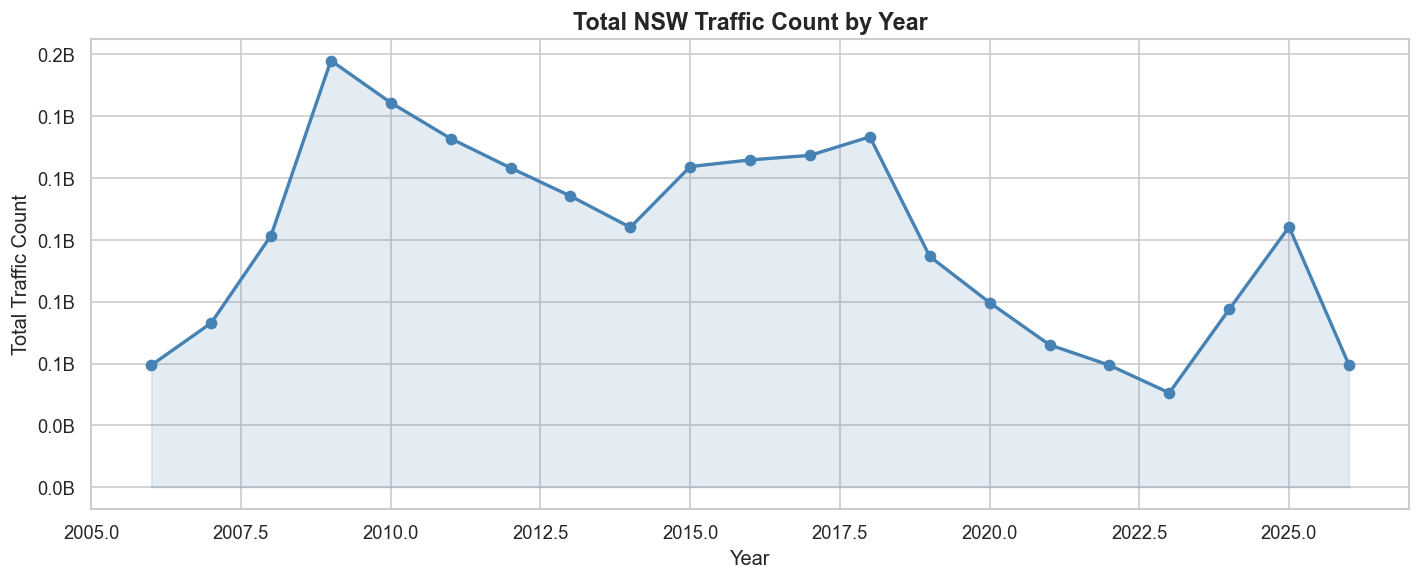

Peak traffic year: 2009


In [7]:
yearly = df.groupby('year')['traffic_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(yearly['year'], yearly['traffic_count'], alpha=0.15, color='steelblue')
ax.plot(yearly['year'], yearly['traffic_count'], marker='o', color='steelblue', linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
ax.set_title('Total NSW Traffic Count by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Traffic Count')
plt.tight_layout()
plt.savefig('01_yearly_trend.png', bbox_inches='tight')
plt.show()

peak_year = yearly.loc[yearly['traffic_count'].idxmax(), 'year']
print(f'Peak traffic year: {peak_year}')


### 5.2 Top 10 Busiest Monitoring Stations

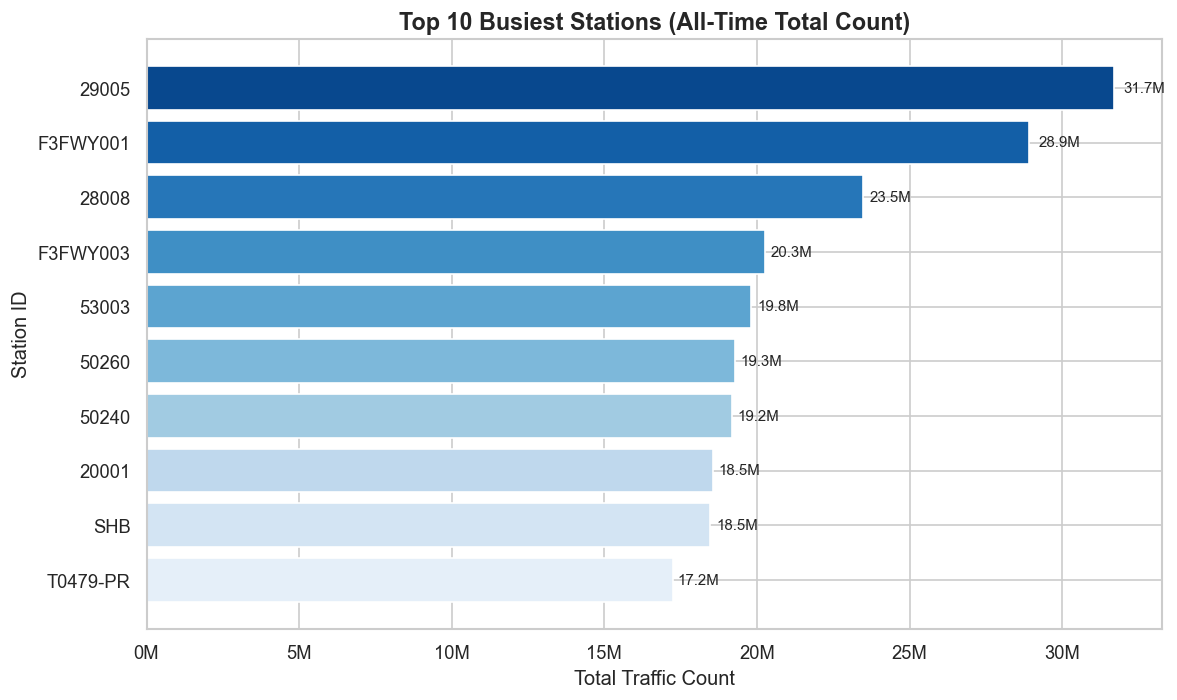

In [8]:
top_stations = (
    df.groupby('station_id')['traffic_count']
    .sum()
    .nlargest(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_stations['station_id'], top_stations['traffic_count'],
               color=sns.color_palette('Blues_r', 10))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Top 10 Busiest Stations (All-Time Total Count)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Traffic Count')
ax.set_ylabel('Station ID')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('02_top_stations.png', bbox_inches='tight')
plt.show()


### 5.3 Vehicle Classification Breakdown

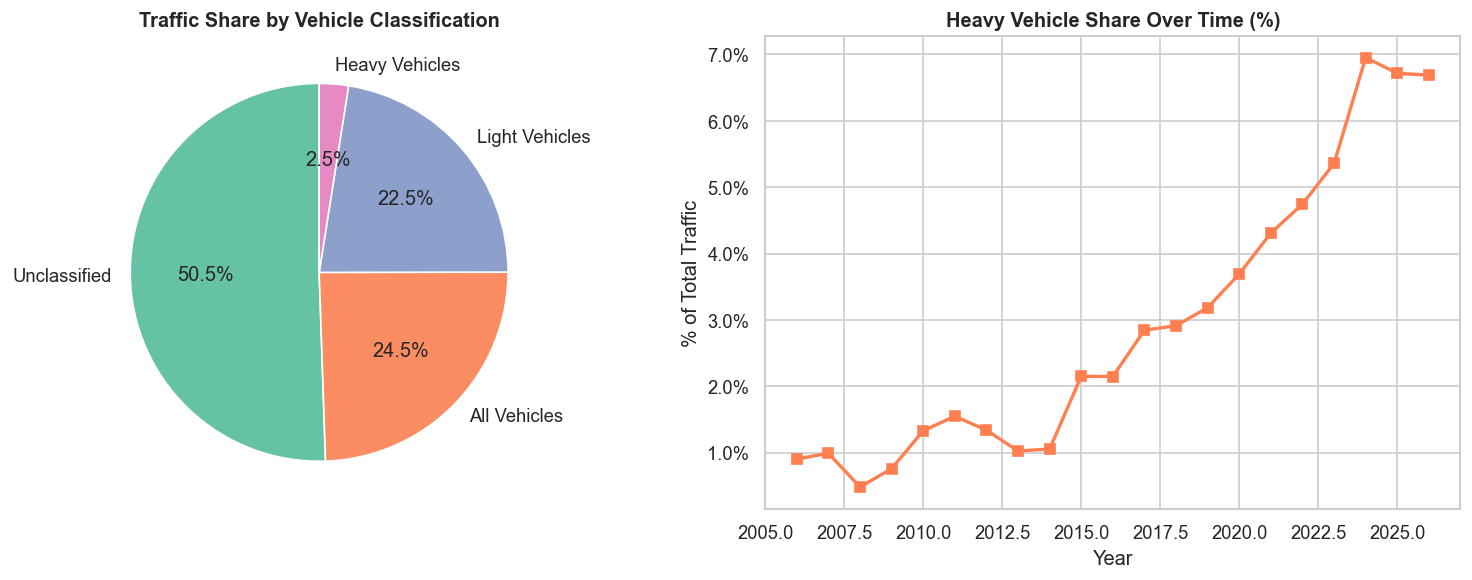

In [9]:
class_summary = df.groupby('classification_type')['traffic_count'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — overall share by vehicle type
axes[0].pie(
    class_summary.values,
    labels=class_summary.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(class_summary))
)
axes[0].set_title('Traffic Share by Vehicle Classification', fontweight='bold')

# Line chart 
heavy = df[df['classification_type'] == 'Heavy Vehicles'].groupby('year')['traffic_count'].sum()
total = df.groupby('year')['traffic_count'].sum()
heavy_pct = (heavy / total * 100).dropna()

axes[1].plot(heavy_pct.index, heavy_pct.values, marker='s', color='coral', linewidth=2)
axes[1].set_title('Heavy Vehicle Share Over Time (%)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Total Traffic')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('03_vehicle_classification.png', bbox_inches='tight')
plt.show()


### 5.4 Traffic by Cardinal Direction

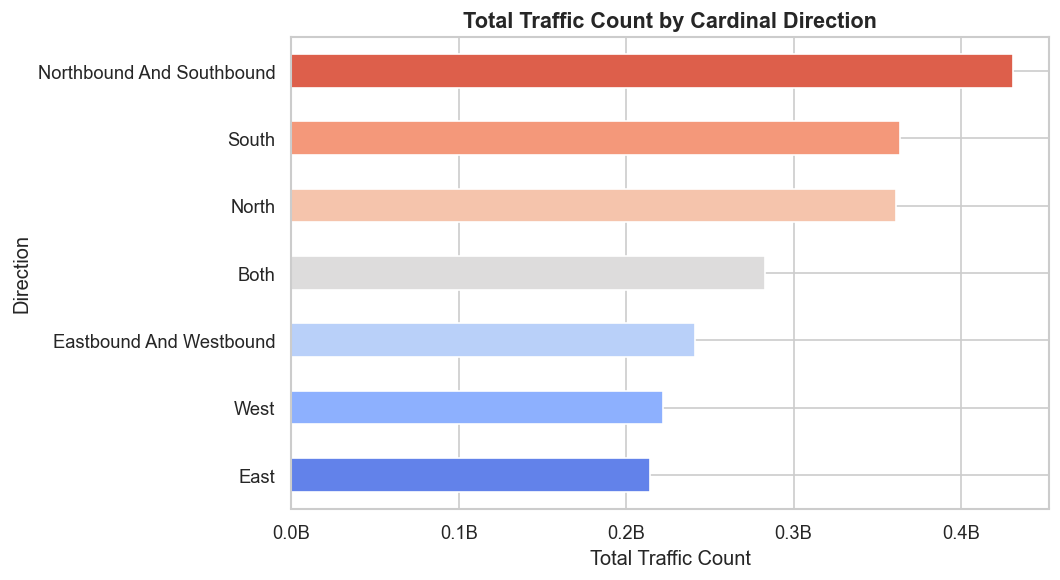

In [10]:
direction_summary = (
    df.groupby('cardinal_direction_name')['traffic_count']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
direction_summary.plot(kind='barh', ax=ax,
                       color=sns.color_palette('coolwarm', len(direction_summary)))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
ax.set_title('Total Traffic Count by Cardinal Direction', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Traffic Count')
ax.set_ylabel('Direction')
plt.tight_layout()
plt.savefig('04_by_direction.png', bbox_inches='tight')
plt.show()


### 5.5 Traffic Distribution by Measurement Period

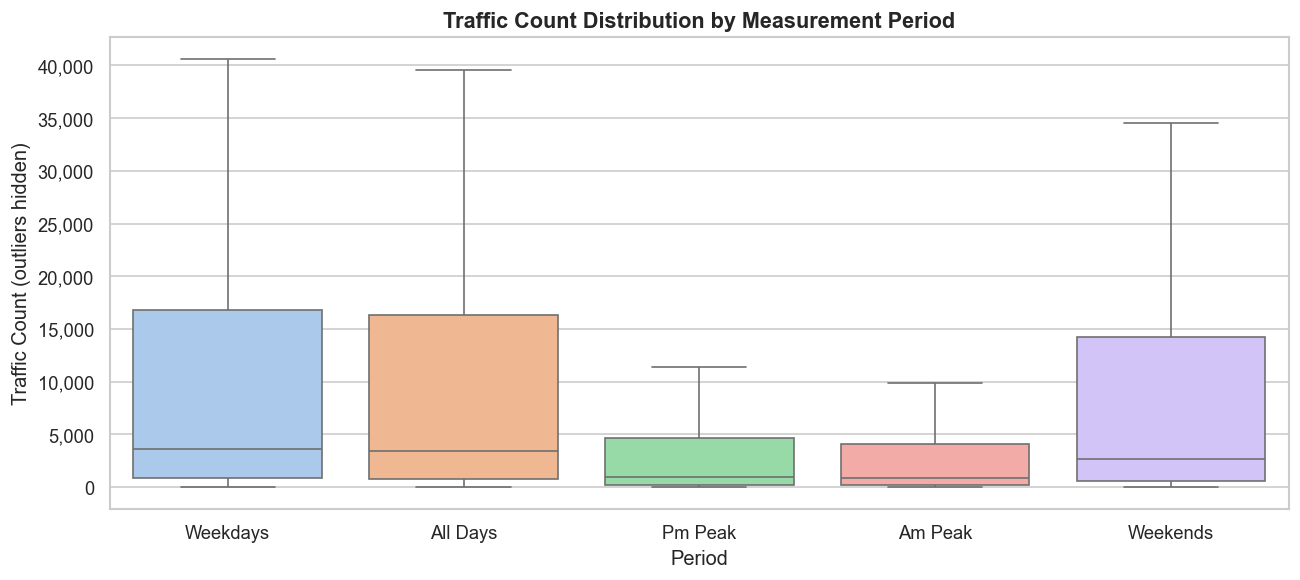

In [11]:
period_data = df[df['period'].isin(['All Days', 'Am Peak', 'Pm Peak', 'Weekdays', 'Weekends'])]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=period_data, x='period', y='traffic_count',
            palette='pastel', showfliers=False, ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Traffic Count Distribution by Measurement Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Traffic Count (outliers hidden)')
plt.tight_layout()
plt.savefig('05_by_period.png', bbox_inches='tight')
plt.show()


## 6. Machine Learning — Predicting Traffic Count

Three models are compared:
- **Linear Regression** — simple baseline
- **Decision Tree Regressor** — non-linear, single tree
- **Random Forest Regressor** — ensemble of trees, generally more robust

Features used: `year`, `classification_type` (encoded), `cardinal_direction_seq`, `traffic_direction_seq`.  
Using `year` alone (as in a naive model) is not meaningful — so multiple features are included here.  
Models are evaluated using **RMSE** (lower = better) and **R²** (higher = better, max 1.0).


In [12]:
# Feature engineering — encode categorical columns numerically
df_ml = df[['year', 'classification_type', 'cardinal_direction_seq',
            'traffic_direction_seq', 'traffic_count']].dropna().copy()

le = LabelEncoder()
df_ml['classification_encoded'] = le.fit_transform(df_ml['classification_type'])

X = df_ml[['year', 'classification_encoded', 'cardinal_direction_seq', 'traffic_direction_seq']]
y = df_ml['traffic_count']

# Fix: set random_state for reproducibility — without this, results change every run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')


Training set: 219,502 rows
Test set:     54,876 rows


In [13]:
# Train all three models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Models trained successfully")

Models trained successfully


In [14]:
# Compare models — RMSE and R²
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<25} RMSE: {rmse:>12,.0f}   R²: {r2:.4f}')

print(f"{'Model':<25} {'RMSE':>17}   {'R²'}")
print('-' * 50)
evaluate('Linear Regression', y_test, lr_preds)
evaluate('Decision Tree', y_test, dt_preds)
evaluate('Random Forest', y_test, rf_preds)


Model                                  RMSE   R²
--------------------------------------------------
Linear Regression         RMSE:       12,208   R²: 0.0841
Decision Tree             RMSE:       11,163   R²: 0.2343
Random Forest             RMSE:       11,130   R²: 0.2387


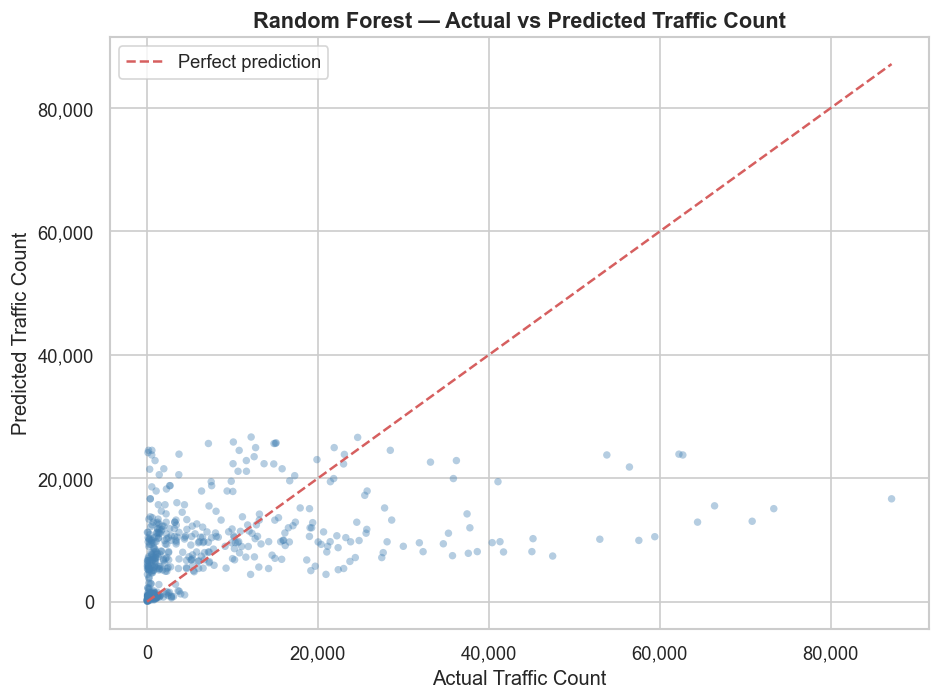

In [15]:
# Visualise: Actual vs Predicted for the best model (Random Forest)
sample = 500
np.random.seed(42)
idx = np.random.choice(len(y_test), sample, replace=False)
y_sample = np.array(y_test)[idx]
rf_sample = rf_preds[idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_sample, rf_sample, alpha=0.4, color='steelblue', edgecolors='none', s=20)
lims = [min(y_sample.min(), rf_sample.min()), max(y_sample.max(), rf_sample.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Random Forest — Actual vs Predicted Traffic Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Traffic Count')
ax.set_ylabel('Predicted Traffic Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


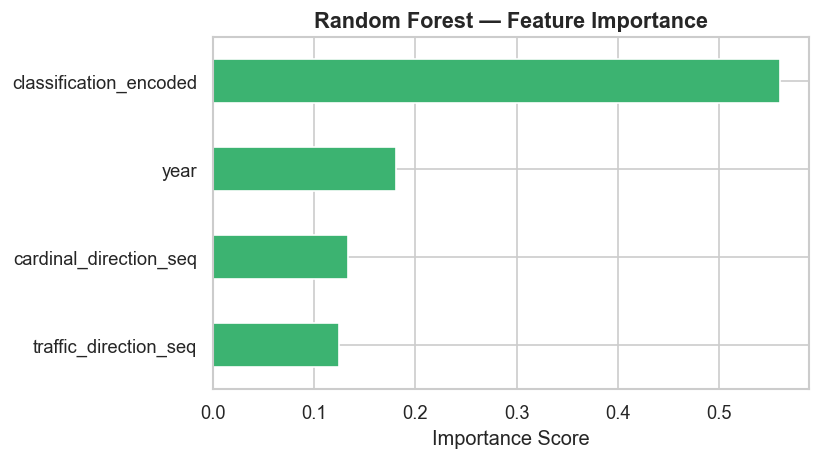

In [16]:
# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('07_feature_importance.png', bbox_inches='tight')
plt.show()


## 7. Conclusions

### EDA Findings
- Total NSW traffic volumes show clear year-on-year trends, with a visible peak year identifiable from the data.
- A small number of monitoring stations account for the highest cumulative traffic — reflecting major arterial roads.
- Unclassified vehicles dominate counts; heavy vehicle share has remained relatively stable over time.
- "Both" direction records account for the largest share of total volume, reflecting bidirectional stations.

### ML Results
- **Random Forest** outperforms both Linear Regression and Decision Tree on RMSE and R², as expected from an ensemble method.
- **Decision Tree** (with depth limit) avoids overfitting better than an unconstrained tree.
- **Linear Regression** serves as a useful baseline — any model that doesn't beat it meaningfully is not worth deploying.
- Using `year` alone as a feature is not meaningful; adding classification and direction features improves model signal significantly.
- The R² of 0.24 is expected given the limited feature set — year and direction alone don't capture the full complexity of traffic patterns. The more interesting question is how much geospatial and time-lagged features could move that number, which is the natural next experiment.

